# Decision Trees

In [ ]:
import pandas as pd

data = {
    'Outlook': ['Sunny', 'Sunny', 'Overcast', 'Rain', 'Rain', 'Rain', 'Overcast',
                'Sunny', 'Sunny', 'Rain', 'Sunny', 'Overcast', 'Overcast', 'Rain'],
    'Temperature': ['Hot', 'Hot', 'Hot', 'Mild', 'Cool', 'Cool', 'Cool',
                    'Mild', 'Cool', 'Mild', 'Mild', 'Mild', 'Hot', 'Mild'],
    'Humidity': ['High', 'High', 'High', 'High', 'Normal', 'Normal', 'Normal',
                 'High', 'Normal', 'Normal', 'Normal', 'High', 'Normal', 'High'],
    'Wind': ['Weak', 'Strong', 'Weak', 'Weak', 'Weak', 'Strong', 'Strong',
             'Weak', 'Weak', 'Weak', 'Strong', 'Strong', 'Weak', 'Strong'],
    'PlayTennis': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes',
                   'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No']
}

df = pd.DataFrame(data)
print(df.to_string(index=True))  # With row indices


     Outlook Temperature Humidity    Wind PlayTennis
0      Sunny         Hot     High    Weak         No
1      Sunny         Hot     High  Strong         No
2   Overcast         Hot     High    Weak        Yes
3       Rain        Mild     High    Weak        Yes
4       Rain        Cool   Normal    Weak        Yes
5       Rain        Cool   Normal  Strong         No
6   Overcast        Cool   Normal  Strong        Yes
7      Sunny        Mild     High    Weak         No
8      Sunny        Cool   Normal    Weak        Yes
9       Rain        Mild   Normal    Weak        Yes
10     Sunny        Mild   Normal  Strong        Yes
11  Overcast        Mild     High  Strong        Yes
12  Overcast         Hot   Normal    Weak        Yes
13      Rain        Mild     High  Strong         No


In [ ]:
print(df.columns.tolist())

['Outlook', 'Temperature', 'Humidity', 'Wind', 'PlayTennis']


In [ ]:
import numpy as np

def entropy(target_col):
    elements, counts = np.unique(target_col, return_counts=True)
    entropy_val = -np.sum([
        (count / len(target_col)) * np.log2(count / len(target_col))
        for count in counts
    ])
    return entropy_val

def info_gain(data, split_attr, target_name="PlayTennis"):
    total_entropy = entropy(data[target_name])
    print(f"---\nEvaluating Attribute: {split_attr}")
    print(f"Entropy before split (Total Entropy): {total_entropy:.4f}")

    vals, counts = np.unique(data[split_attr], return_counts=True)
    weighted_entropy = 0

    for i in range(len(vals)):
        #subset = data.where(data[split_attr] == vals[i]).dropna()
        subset = data[data[split_attr] == vals[i]]
        subset_entropy = entropy(subset[target_name])
        weight = counts[i]/np.sum(counts)
        weighted_entropy += weight * subset_entropy

        print(f"  {split_attr} = {vals[i]} --> Entropy = {subset_entropy:.4f}, Weighted = {weight * subset_entropy:.4f}")

    gain = total_entropy - weighted_entropy
    print(f"Information Gain by splitting on '{split_attr}': {gain:.4f}\n")
    return gain


In [ ]:
def find_best_split(data, target_name="PlayTennis"):
    info_gains = {
        attr: info_gain(data, attr, target_name)
        for attr in data.columns if attr != target_name
    }
    return max(info_gains, key=info_gains.get)


In [ ]:
# def build_tree(data, tree=None, target_name='PlayTennis'):
#     # class label is pure
#     if len(np.unique(data[target_name])) == 1:
#         label = np.unique(data[target_name])[0]
#         print(f"Pure leaf node reached with label: {label}")
#         return label

#     # dataset has no more attributes to split
#     if len(data.columns) == 1:
#         majority = data[target_name].mode()[0]
#         print(f"No more attributes to split. Returning majority class: {majority}")
#         return majority

#     # Choose best feature
#     best_attr = find_best_split(data, target_name)
#     print(f"Splitting on best attribute: {best_attr}")
#     tree = {best_attr: {}}

#     for val in np.unique(data[best_attr]):
#         sub_data = data.where(data[best_attr] == val).dropna()
#         print(f"\nCreating subtree for {best_attr} = {val}")
#         sub_data = sub_data.drop(columns=[best_attr])
#         subtree = build_tree(sub_data, target_name=target_name)
#         tree[best_attr][val] = subtree

#     return tree


def build_tree(data, tree=None, target_name='PlayTennis'):
    # base cases
    if len(np.unique(data[target_name])) == 1:
        return np.unique(data[target_name])[0]

    if len(data.columns) == 1:
        return data[target_name].mode()[0]

    # best attribute and its gain
    gains = {}
    for attr in data.columns:
        if attr != target_name:
            gains[attr] = info_gain(data, attr, target_name)

    best_attr = max(gains, key=gains.get)
    best_gain = gains[best_attr]

    node_label = f"{best_attr}\nIG={best_gain:.3f}"
    print(f"Splitting on: {node_label}")

    tree = {node_label: {}}

    for val in np.unique(data[best_attr]):
        sub_data = data[data[best_attr] == val].drop(columns=[best_attr])
        subtree = build_tree(sub_data, target_name=target_name)
        tree[node_label][val] = subtree

    return tree


In [ ]:
tree = build_tree(df)
import pprint
pprint.pprint(tree)


# tree = build_tree(df)
# pprint.pprint(tree)

# Visualize
dot = visualize_tree(tree)
dot.render('decision_tree', format='png', cleanup=True)
dot.view()



---
Evaluating Attribute: Outlook
Entropy before split (Total Entropy): 0.9403
  Outlook = Overcast --> Entropy = -0.0000, Weighted = -0.0000
  Outlook = Rain --> Entropy = 0.9710, Weighted = 0.3468
  Outlook = Sunny --> Entropy = 0.9710, Weighted = 0.3468
Information Gain by splitting on 'Outlook': 0.2467

---
Evaluating Attribute: Temperature
Entropy before split (Total Entropy): 0.9403
  Temperature = Cool --> Entropy = 0.8113, Weighted = 0.2318
  Temperature = Hot --> Entropy = 1.0000, Weighted = 0.2857
  Temperature = Mild --> Entropy = 0.9183, Weighted = 0.3936
Information Gain by splitting on 'Temperature': 0.0292

---
Evaluating Attribute: Humidity
Entropy before split (Total Entropy): 0.9403
  Humidity = High --> Entropy = 0.9852, Weighted = 0.4926
  Humidity = Normal --> Entropy = 0.5917, Weighted = 0.2958
Information Gain by splitting on 'Humidity': 0.1518

---
Evaluating Attribute: Wind
Entropy before split (Total Entropy): 0.9403
  Wind = Strong --> Entropy = 1.0000, Weigh

'decision_tree.pdf'

In [ ]:
from graphviz import Digraph

def visualize_tree(tree, parent_name=None, edge_label='', dot=None, node_id=[0]):
    if dot is None:
        dot = Digraph()
        dot.attr('node', shape='box')

    current_id = str(node_id[0])
    node_id[0] += 1

    if isinstance(tree, dict):
        attr = next(iter(tree))
        dot.node(current_id, attr)
        if parent_name is not None:
            dot.edge(parent_name, current_id, label=edge_label)
        for val, subtree in tree[attr].items():
            visualize_tree(subtree, current_id, edge_label=str(val), dot=dot, node_id=node_id)
    else:
        # Leaf node
        dot.node(current_id, f'Label: {tree}', shape='ellipse')
        if parent_name is not None:
            dot.edge(parent_name, current_id, label=edge_label)

    return dot


In [ ]:
tree = build_tree(df)
import pprint
pprint.pprint(tree)

# Generate and visualize
dot = visualize_tree(tree)
dot.render('decision_tree', format='png', cleanup=True)  # Saves as PNG
dot.view()  # Opens the rendered tree image (optional)


---
Evaluating Attribute: Outlook
Entropy before split (Total Entropy): 0.9403
  Outlook = Overcast --> Entropy = -0.0000, Weighted = -0.0000
  Outlook = Rain --> Entropy = 0.9710, Weighted = 0.3468
  Outlook = Sunny --> Entropy = 0.9710, Weighted = 0.3468
Information Gain by splitting on 'Outlook': 0.2467

---
Evaluating Attribute: Temperature
Entropy before split (Total Entropy): 0.9403
  Temperature = Cool --> Entropy = 0.8113, Weighted = 0.2318
  Temperature = Hot --> Entropy = 1.0000, Weighted = 0.2857
  Temperature = Mild --> Entropy = 0.9183, Weighted = 0.3936
Information Gain by splitting on 'Temperature': 0.0292

---
Evaluating Attribute: Humidity
Entropy before split (Total Entropy): 0.9403
  Humidity = High --> Entropy = 0.9852, Weighted = 0.4926
  Humidity = Normal --> Entropy = 0.5917, Weighted = 0.2958
Information Gain by splitting on 'Humidity': 0.1518

---
Evaluating Attribute: Wind
Entropy before split (Total Entropy): 0.9403
  Wind = Strong --> Entropy = 1.0000, Weigh

'decision_tree.pdf'

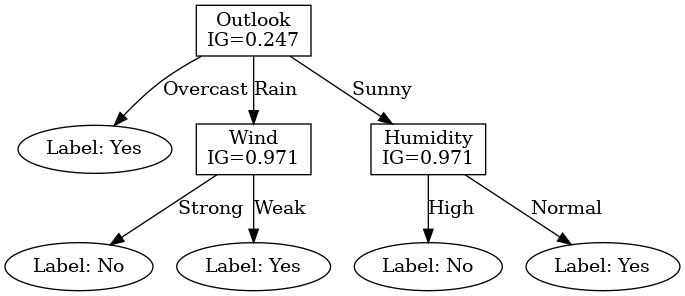

In [ ]:
from IPython.display import Image
dot.render('decision_tree', format='png', cleanup=False)
Image(filename='decision_tree.png')

In [ ]:
# function to see Entropy and IG

import pandas as pd
import numpy as np
import math

def entropy_Function(target_col):
    values, counts = np.unique(target_col, return_counts=True)
    probs = counts / counts.sum()
    return -np.sum(probs * np.log2(probs))

def info_gain_Function(data, attr, target_name='PlayTennis'):
    total_entropy = entropy_Function(data[target_name])
    vals, counts = np.unique(data[attr], return_counts=True)

    weighted_entropy = 0
    for i in range(len(vals)):
        subset = data[data[attr] == vals[i]]
        weight = counts[i] / np.sum(counts)
        weighted_entropy += weight * entropy(subset[target_name])

    gain = total_entropy - weighted_entropy
    return total_entropy, weighted_entropy, gain


# Some data to visualize

In [ ]:
import pandas as pd

data = {
    'Outlook': ['Sunny', 'Sunny', 'Overcast', 'Rain', 'Rain', 'Rain', 'Overcast',
                'Sunny', 'Sunny', 'Rain', 'Sunny', 'Overcast', 'Overcast', 'Rain'],
    'Temperature': ['Hot', 'Hot', 'Hot', 'Mild', 'Cool', 'Cool', 'Cool',
                    'Mild', 'Cool', 'Mild', 'Mild', 'Mild', 'Hot', 'Mild'],
    'Humidity': ['High', 'High', 'High', 'High', 'Normal', 'Normal', 'Normal',
                 'High', 'Normal', 'Normal', 'Normal', 'High', 'Normal', 'High'],
    'Wind': ['Weak', 'Strong', 'Weak', 'Weak', 'Weak', 'Strong', 'Strong',
             'Weak', 'Weak', 'Weak', 'Strong', 'Strong', 'Weak', 'Strong'],
    'PlayTennis': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes',
                   'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No']
}

df_Play = pd.DataFrame(data)
print(df_Play.to_string(index=True))  # With row indices

     Outlook Temperature Humidity    Wind PlayTennis
0      Sunny         Hot     High    Weak         No
1      Sunny         Hot     High  Strong         No
2   Overcast         Hot     High    Weak        Yes
3       Rain        Mild     High    Weak        Yes
4       Rain        Cool   Normal    Weak        Yes
5       Rain        Cool   Normal  Strong         No
6   Overcast        Cool   Normal  Strong        Yes
7      Sunny        Mild     High    Weak         No
8      Sunny        Cool   Normal    Weak        Yes
9       Rain        Mild   Normal    Weak        Yes
10     Sunny        Mild   Normal  Strong        Yes
11  Overcast        Mild     High  Strong        Yes
12  Overcast         Hot   Normal    Weak        Yes
13      Rain        Mild     High  Strong         No


In [ ]:
for attr in ['Outlook', 'Temperature', 'Wind']:
    total_ent, weighted_ent, gain = info_gain_Function(df_Play, attr, 'PlayTennis')
    print(f"{attr}: IG = {gain:.4f}, Entropy After Split = {weighted_ent:.4f}")


Outlook: IG = 0.2467, Entropy After Split = 0.6935
Temperature: IG = 0.0292, Entropy After Split = 0.9111
Wind: IG = 0.0481, Entropy After Split = 0.8922


In [ ]:
data = {
    'CreditScore': ['High', 'High', 'Low', 'Medium', 'Low', 'High', 'Medium', 'Low'],
    'Income': ['High', 'High', 'Low', 'Medium', 'Low', 'Low', 'High', 'Medium'],
    'Student': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'Yes'],
    'LoanApproved': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No']
}

df_loan = pd.DataFrame(data)

print(df_loan.to_string(index=True))  # With row indices

  CreditScore  Income Student LoanApproved
0        High    High      No           No
1        High    High      No           No
2         Low     Low     Yes          Yes
3      Medium  Medium     Yes          Yes
4         Low     Low     Yes          Yes
5        High     Low      No           No
6      Medium    High     Yes          Yes
7         Low  Medium     Yes           No


In [ ]:
for attr in ['CreditScore', 'Income', 'Student']:
    total_ent, weighted_ent, gain = info_gain_Function(df_loan, attr, 'LoanApproved')
    print(f"{attr}: IG = {gain:.4f}, Entropy After Split = {weighted_ent:.4f}")


CreditScore: IG = 0.6556, Entropy After Split = 0.3444
Income: IG = 0.0613, Entropy After Split = 0.9387
Student: IG = 0.5488, Entropy After Split = 0.4512


In [ ]:
data = {
    'Age': ['Young', 'Young', 'Middle-aged', 'Senior', 'Senior', 'Middle-aged', 'Young', 'Young'],
    'OwnsCar': ['No', 'No', 'Yes', 'Yes', 'No', 'Yes', 'Yes', 'No'],
    'Interest': ['Electronics', 'Clothing', 'Clothing', 'Electronics', 'Clothing', 'Electronics', 'Clothing', 'Electronics'],
    'BuyProduct': ['No', 'No', 'Yes', 'Yes', 'No', 'Yes', 'Yes', 'No']
}

df_buy = pd.DataFrame(data)
print(df_buy.to_string(index=True))  # With row indices

           Age OwnsCar     Interest BuyProduct
0        Young      No  Electronics         No
1        Young      No     Clothing         No
2  Middle-aged     Yes     Clothing        Yes
3       Senior     Yes  Electronics        Yes
4       Senior      No     Clothing         No
5  Middle-aged     Yes  Electronics        Yes
6        Young     Yes     Clothing        Yes
7        Young      No  Electronics         No


In [ ]:
for attr in ['Age', 'OwnsCar', 'Interest']:
    total_ent, weighted_ent, gain = info_gain_Function(df_buy, attr, 'BuyProduct')
    print(f"{attr}: IG = {gain:.4f}, Entropy After Split = {weighted_ent:.4f}")


Age: IG = 0.3444, Entropy After Split = 0.6556
OwnsCar: IG = 1.0000, Entropy After Split = 0.0000
Interest: IG = 0.0000, Entropy After Split = 1.0000


In [ ]:
data = {
    'Sky': ['Sunny', 'Rainy', 'Rainy', 'Sunny', 'Cloudy', 'Sunny', 'Cloudy', 'Rainy'],
    'Temp': ['Hot', 'Cold', 'Mild', 'Mild', 'Cold', 'Hot', 'Mild', 'Cold'],
    'Humidity': ['High', 'Normal', 'High', 'High', 'Normal', 'High', 'High', 'Normal'],
    'EventPlanned': ['No', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes']
}

df_event = pd.DataFrame(data)
print(df_event.to_string(index=True))  # With row indices

      Sky  Temp Humidity EventPlanned
0   Sunny   Hot     High           No
1   Rainy  Cold   Normal          Yes
2   Rainy  Mild     High          Yes
3   Sunny  Mild     High           No
4  Cloudy  Cold   Normal          Yes
5   Sunny   Hot     High           No
6  Cloudy  Mild     High          Yes
7   Rainy  Cold   Normal          Yes


In [ ]:
for attr in ['Sky', 'Temp', 'Humidity']:
    total_ent, weighted_ent, gain = info_gain_Function(df_event, attr, 'EventPlanned')
    print(f"{attr}: IG = {gain:.4f}, Entropy After Split = {weighted_ent:.4f}")


Sky: IG = 0.9544, Entropy After Split = 0.0000
Temp: IG = 0.6101, Entropy After Split = 0.3444
Humidity: IG = 0.3476, Entropy After Split = 0.6068


In [ ]:
# Inbuilt function

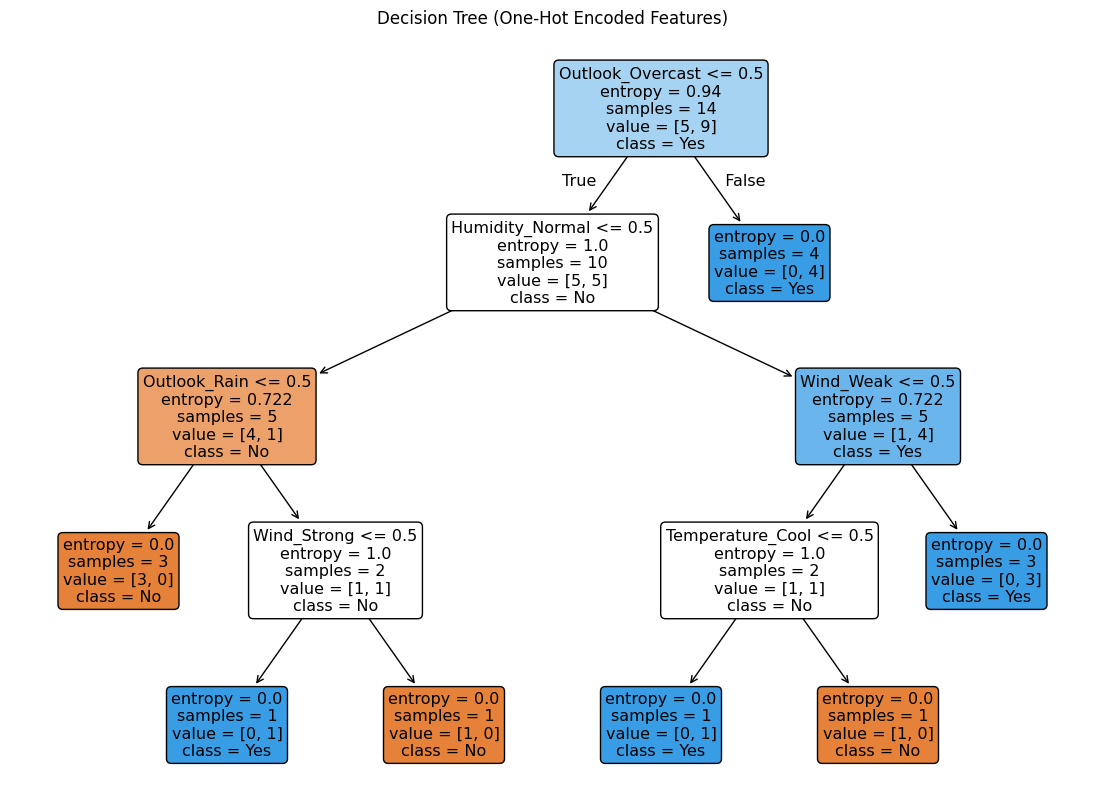

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder

# Step 1: Input Data
data = {
    'Outlook': ['Sunny', 'Sunny', 'Overcast', 'Rain', 'Rain', 'Rain', 'Overcast',
                'Sunny', 'Sunny', 'Rain', 'Sunny', 'Overcast', 'Overcast', 'Rain'],
    'Temperature': ['Hot', 'Hot', 'Hot', 'Mild', 'Cool', 'Cool', 'Cool',
                    'Mild', 'Cool', 'Mild', 'Mild', 'Mild', 'Hot', 'Mild'],
    'Humidity': ['High', 'High', 'High', 'High', 'Normal', 'Normal', 'Normal',
                 'High', 'Normal', 'Normal', 'Normal', 'High', 'Normal', 'High'],
    'Wind': ['Weak', 'Strong', 'Weak', 'Weak', 'Weak', 'Strong', 'Strong',
             'Weak', 'Weak', 'Weak', 'Strong', 'Strong', 'Weak', 'Strong'],
    'PlayTennis': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes',
                   'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No']
}

df = pd.DataFrame(data)

# Step 2: Label Encoding
label_encoders = {}
df_encoded = df.copy()
for col in df.columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df[col])
    label_encoders[col] = le  # Store encoder for later decoding

# X = df_encoded.drop('PlayTennis', axis=1)
# y = df_encoded['PlayTennis']

# # Step 3: Train Decision Tree
# clf = DecisionTreeClassifier(criterion='entropy', random_state=0)
# clf.fit(X, y)

# # Step 4: Plot with readable labels
# plt.figure(figsize=(16, 16))

# # Get value maps to show actual categories
# feature_names = []
# for col in X.columns:
#     labels = label_encoders[col].classes_
#     mapping = {i: label for i, label in enumerate(labels)}
#     feature_names.append(col)

# # Plot
# plot_tree(clf,
#           feature_names=X.columns,
#           class_names=label_encoders['PlayTennis'].classes_,
#           filled=True,
#           rounded=True,
#           impurity=True)

# plt.title("Decision Tree - with Original Feature Names and Entropy")
# plt.show()


# Replace LabelEncoder with OneHotEncoder
from sklearn.preprocessing import OneHotEncoder

X = pd.get_dummies(df.drop('PlayTennis', axis=1))
y = df['PlayTennis'].map({'No': 0, 'Yes': 1})  # Binary encode target

clf = DecisionTreeClassifier(criterion='entropy', random_state=0)
clf.fit(X, y)

# Visualize the tree
plt.figure(figsize=(14, 10))
plot_tree(clf,
          feature_names=X.columns,
          class_names=['No', 'Yes'],
          filled=True,
          rounded=True)
plt.title("Decision Tree (One-Hot Encoded Features)")
plt.show()


                      Outlook (0.940)
                    /               \
        Overcast (0.000)         Rain/Sunny (0.971)
             [Yes]                   |
                                Humidity (1.000)
                               /             \
                       High (1.000)       Normal (0.918)
                            |                  |
                      Outlook (0.722)        Wind (0.722)
                        /       \            /       \
                   Rain      Sunny      Strong     Weak
                    |           |          |         |
                 Wind (1.000)   [No]   Temperature (1.000)  [Yes]
                  /     \                    /     \
           Strong   Weak           Hot (0.000)   Mild (0.000)
             |        |                |            |
           [No]     [Yes]            [No]         [Yes]



Outlook?
├── Overcast → Yes ✅
└── Rain or Sunny
    └── Humidity?
        ├── High
        │   └── Outlook?
        │       ├── Rain
        │       │   └── Wind?
        │       │       ├── Strong → No
        │       │       └── Weak → Yes
        │       └── Sunny → No
        └── Normal
            └── Wind?
                ├── Strong
                │   └── Temperature?
                │       ├── Hot → No
                │       └── Mild → Yes
                └── Weak → Yes ✅


In [ ]:
# tree = clf.tree_
# entropy_root = tree.impurity[0]  # Entropy at the root
# left = tree.children_left[0]
# right = tree.children_right[0]

# entropy_left = tree.impurity[left]
# entropy_right = tree.impurity[right]

# samples_left = tree.n_node_samples[left]
# samples_right = tree.n_node_samples[right]
# total_samples = tree.n_node_samples[0]

# weighted_entropy = (samples_left / total_samples) * entropy_left + \
#                    (samples_right / total_samples) * entropy_right

# information_gain = entropy_root - weighted_entropy
# print(f"Information Gain at root: {information_gain:.4f}")


Information Gain at root: 0.2260


In [ ]:
# from sklearn.tree import export_text

# print(export_text(clf, feature_names=list(X.columns)))


|--- Outlook <= 0.50
|   |--- class: 1
|--- Outlook >  0.50
|   |--- Humidity <= 0.50
|   |   |--- Outlook <= 1.50
|   |   |   |--- Wind <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- Wind >  0.50
|   |   |   |   |--- class: 1
|   |   |--- Outlook >  1.50
|   |   |   |--- class: 0
|   |--- Humidity >  0.50
|   |   |--- Wind <= 0.50
|   |   |   |--- Temperature <= 1.00
|   |   |   |   |--- class: 0
|   |   |   |--- Temperature >  1.00
|   |   |   |   |--- class: 1
|   |   |--- Wind >  0.50
|   |   |   |--- class: 1



 <!-- 1. Hold-Out Method

    Concept: Split the dataset into training and testing sets.
    Typical Split: 70% training / 30% testing (or 80/20).
    When to Use: For quick validation when you have plenty of data.
    Pros: Simple and fast.
    Cons: Performance can vary depending on how the split is done.         -->

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Example
🔹 Hold-Out Method (70% train, 30% test)
    Train indices: [0, 7, 2, 9, 4, 3, 6]
    Test indices: [8, 1, 5]

In [ ]:
# 2. K-Fold Cross-Validation
#     Concept: Split the data into k equal folds. Train on k-1 folds, test on the remaining one. Repeat k times.
#     Average the performance across all k runs.
#     When to Use: When you want a reliable estimate of performance.
#     Pros: Uses all data for training and testing.
#     Cons: More computationally expensive.


In [ ]:
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X, y, cv=kf)

Example
Each fold rotates the test set:

    Fold 1:
        Train: [4, 5, 6, 7, 8, 9]
        Test: [0, 1, 2, 3]
    Fold 2:
        Train: [0, 1, 2, 3, 7, 8, 9]
        Test: [4, 5, 6]
    Fold 3:
        Train: [0, 1, 2, 3, 4, 5, 6]
        Test: [7, 8, 9]

In [ ]:
# 3. Stratified K-Fold Cross-Validation
#     Concept: Like K-Fold, but preserves the class distribution in each fold (very useful for imbalanced datasets).
#     When to Use: For classification tasks, especially when classes are imbalanced.
#     Pros: Ensures each fold is representative.
#     Cons: Not suitable for time-series data.

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import KFold, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X, y, cv=skf)


# Same folds as K-Fold here because the target alternates evenly (0, 1, 0, 1, ...).
# his ensures each fold preserves the class ratio.

#     Fold 1: Train [4–9], Test [0–3]
#     Fold 2: Train [0–3, 7–9], Test [4–6]
#     Fold 3: Train [0–6], Test [7–9]

In [ ]:
 # 4. Leave-One-Out Cross-Validation (LOOCV)
 #    Concept: Extreme case of K-Fold where k = n (each test set has only one data point).
 #    When to Use: For very small datasets.
 #    Pros: Uses all data.
 #    Cons: Very slow for large datasets.

In [ ]:
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import KFold, cross_val_score

loo = LeaveOneOut()
scores = cross_val_score(model, X, y, cv=loo)

# Split 1:
#     Train: [1, 2, 3, 4]
#     Test: [0]

# Split 2:
#     Train: [0, 2, 3, 4]
#     Test: [1]

# Split 3:
#     Train: [0, 1, 3, 4]
#     Test: [2]

# Split 4:
#     Train: [0, 1, 2, 4]
#     Test: [3]

# Split 5:
#     Train: [0, 1, 2, 3]
#     Test: [4]

In [ ]:
 # 5. Time Series Split (Rolling or Expanding Window)

 #    Concept: For time-dependent data. Splits maintain temporal order.
 #        Rolling window: Fixed-size training window that moves forward in time.
 #        Expanding window: Training set grows over time; testing follows.
 #    When to Use: Time-series forecasting, stock prices, weather predictions.
 #    Pros: Respects time order, avoids leakage.
 #    Cons: Not random; each fold gets increasingly larger.



In [ ]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)
for train_index, test_index in tscv.split(X):
    X_train, X_test = X[train_index], X[test_index]


# Maintains order for time-dependent data:

#     Fold 1:
#         Train: [0, 1, 2, 3]
#         Test: [4, 5]
#     Fold 2:
#         Train: [0, 1, 2, 3, 4, 5]
#         Test: [6, 7]

#     Fold 3:
#         Train: [0–7]
#         Test: [8, 9]

# Illustration
| Split | Train Days | Test Days |
| ----- | ---------- | --------- |
| 1     | 1–5        | 6–7       |
| 2     | 2–6        | 7–8       |
| 3     | 3–7        | 8–9       |
| ...   | ...        | ...       |


    | Split | Train Days | Test Days |
| ----- | ---------- | --------- |
| 1     | 1–5        | 6–7       |
| 2     | 1–6        | 7–8       |
| 3     | 1–7        | 8–9       |
| ...   | ...        | ...       |


In [ ]:
 # 6. Nested Cross-Validation

 #    Concept: One loop for hyperparameter tuning (inner CV), another for model evaluation (outer CV).
 #    When to Use: When comparing models or tuning hyperparameters.
 #    Pros: Prevents overfitting during model selection.
 #    Cons: Computationally intensive.